# AI Productivity Maximizer for Students (Runnable Version)


Dataset: **student_habits_performance.csv**

1. Load and clean data
2. Build performance classification model (High vs Low)
4. Evaluate model
5. Generate a simple priority-based study schedule

Models:
1. RandomForest
2. MultiRegression
3. NeuralNetwork

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [3]:
# IMPORTANT: Keep the CSV in same folder as notebook
df = pd.read_csv('student_habits_performance.csv')
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## 3. Dataset Overview

In [4]:
print('Shape:', df.shape)
df.info()

Shape: (1000, 16)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-nu

## 4. Handle Missing Values + Basic Cleaning

In [5]:
print('Missing values before:')
print(df.isnull().sum())

# Remove ID column if exists
if 'student_id' in df.columns:
    df.drop(columns=['student_id'], inplace=True)

# Fill missing categorical values with mode
df.fillna(df.mode().iloc[0], inplace=True)

print('\nMissing values after:')
print(df.isnull().sum())

Missing values before:
student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

Missing values after:
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_educat

## 5. Encode Categorical Features

In [6]:
le_dict = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

df.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,0,0.0,1.2,1.1,0,85.0,8.0,0,6,2,0,8,1,56.2
1,20,0,6.9,2.8,2.3,0,97.3,4.6,1,6,1,0,8,0,100.0
2,21,1,1.4,3.1,1.3,0,94.8,8.0,2,1,1,2,1,0,34.3
3,23,0,1.0,3.9,1.0,0,71.0,9.2,2,4,2,1,1,1,26.8
4,19,0,5.0,4.4,0.5,0,90.9,4.9,0,3,2,1,1,0,66.4


## 6. Create Target Variable (Binary Performance)

In [7]:
# Preserve original score for regression
exam_score_backup = df['exam_score'].copy()  # .copy() is important!

# exam_score >= 70 => High Performance (1), else Low Performance (0)
df['performance'] = df['exam_score'].apply(lambda x: 1 if x >= 70 else 0)
df.drop(columns=['exam_score'], inplace=True)

df['performance'].value_counts()

performance
1    511
0    489
Name: count, dtype: int64

## 7. EDA

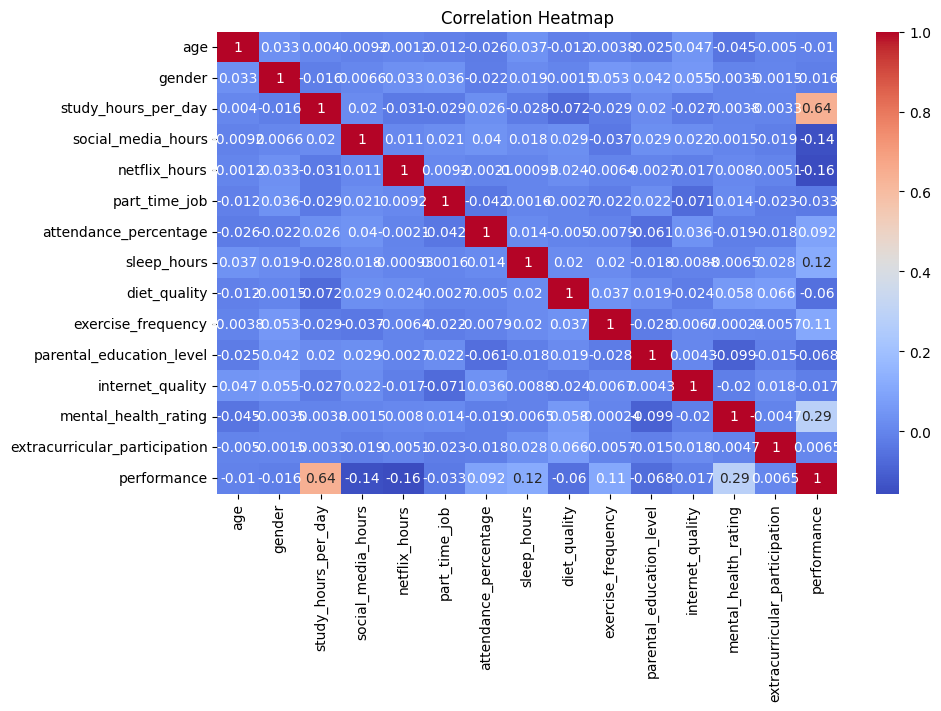

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 8. Train/Test Split

In [9]:
X = df.drop(columns=['performance'])
y = df['performance']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train:', X_train.shape)
print('Test :', X_test.shape)

Train: (800, 14)
Test : (200, 14)


## 9. Train Model

In [10]:
model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## 10. Evaluate Model

In [11]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Accuracy :', round(acc,4))
print('Precision:', round(prec,4))
print('Recall   :', round(rec,4))
print('F1 Score :', round(f1,4))

print('\nClassification Report:\n')
print(classification_report(y_test, y_pred))

Accuracy : 0.85
Precision: 0.8713
Recall   : 0.8381
F1 Score : 0.8544

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.86      0.85        95
           1       0.87      0.84      0.85       105

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200



## 11. Confusion Matrix

[[82 13]
 [17 88]]


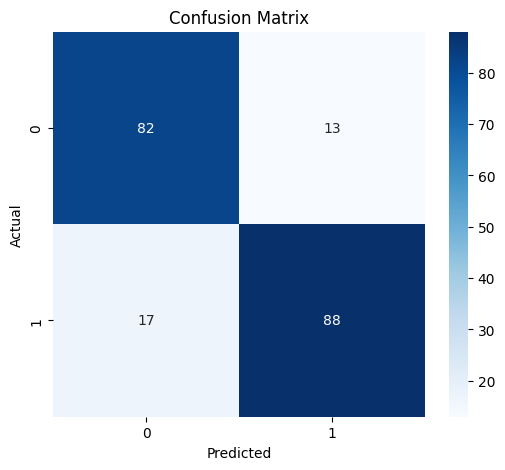

In [12]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [13]:
# =========================
# REGRESSION MODEL
# =========================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
df['exam_score'] = exam_score_backup

# Features (drop both targets)
X_reg = df.drop(['exam_score', 'exam_score', 'performance'], axis=1, errors='ignore')
y_reg = df['exam_score']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)

y_pred_reg = lin_reg.predict(X_test_reg)

print("=== Multiple Linear Regression ===")
print("MSE:", mean_squared_error(y_test_reg, y_pred_reg))
print("R2 Score:", r2_score(y_test_reg, y_pred_reg))

=== Multiple Linear Regression ===
MSE: 26.497748783647193
R2 Score: 0.8966663721200843


In [14]:
df.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,performance,exam_score
0,23,0,0.0,1.2,1.1,0,85.0,8.0,0,6,2,0,8,1,0,56.2
1,20,0,6.9,2.8,2.3,0,97.3,4.6,1,6,1,0,8,0,1,100.0
2,21,1,1.4,3.1,1.3,0,94.8,8.0,2,1,1,2,1,0,0,34.3
3,23,0,1.0,3.9,1.0,0,71.0,9.2,2,4,2,1,1,1,0,26.8
4,19,0,5.0,4.4,0.5,0,90.9,4.9,0,3,2,1,1,0,0,66.4


In [15]:
# Binary classification target
df['performance'] = (df['exam_score'] >= df['exam_score'].median()).astype(int)

X = df.drop(['exam_score', 'exam_score', 'performance'], axis=1, errors='ignore')
y = df['performance']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=500)
lr_model.fit(X_train2, y_train2)

y_pred_lr = lr_model.predict(X_test2)

In [17]:
# =========================
# NEURAL NETWORK
# =========================
from sklearn.neural_network import MLPClassifier

nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size='auto',
    learning_rate='adaptive',
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=42
)

nn_model.fit(X_train2, y_train2)
y_pred_nn = nn_model.predict(X_test2)

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def evaluate_model(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")


evaluate_model("Random Forest", y_test, y_pred)
evaluate_model("Logistic Regression", y_test2, y_pred_lr)
evaluate_model("Neural Network", y_test2, y_pred_nn)


=== Random Forest ===
Accuracy:  0.8500
Precision: 0.8713
Recall:    0.8381
F1 Score:  0.8544

=== Logistic Regression ===
Accuracy:  0.9000
Precision: 0.8922
Recall:    0.9100
F1 Score:  0.9010

=== Neural Network ===
Accuracy:  0.8400
Precision: 0.8400
Recall:    0.8400
F1 Score:  0.8400


#### It can be seen that Logistic Regression is performing best with an F1 score of 0.9
#### This would be a good choice in performance predictor

In [19]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Accuracy :', round(acc,4))
print('Precision:', round(prec,4))
print('Recall   :', round(rec,4))
print('F1 Score :', round(f1,4))

print('\nClassification Report:\n')
print(classification_report(y_test, y_pred))

Accuracy : 0.85
Precision: 0.8713
Recall   : 0.8381
F1 Score : 0.8544

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.86      0.85        95
           1       0.87      0.84      0.85       105

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200



## 12. Simple AI Study Scheduler (Rule-Based Prototype)

In [87]:
from datetime import datetime

tasks = [
    {'task':'AI Assignment', 'deadline':'2026-03-20', 'difficulty':5, 'hours':4},
    {'task':'DB Quiz Prep', 'deadline':'2026-03-17', 'difficulty':3, 'hours':2},
    {'task':'OS Midterm Prep', 'deadline':'2026-03-22', 'difficulty':4, 'hours':5},
    {'task':'Math Final Prep', 'deadline':'2026-03-28', 'difficulty':5, 'hours':6}
]

today = datetime.strptime('2026-03-15', '%Y-%m-%d')

def priority_score(task):
    dline = datetime.strptime(task['deadline'], '%Y-%m-%d')
    days_left = max((dline - today).days, 1)
    urgency = 1 / days_left
    return (0.5*urgency) + (0.3*(task['difficulty']/5)) + (0.2*(task['hours']/6))

for t in tasks:
    t['priority'] = round(priority_score(t),4)

tasks_sorted = sorted(tasks, key=lambda x: x['priority'], reverse=True)
schedule_df = pd.DataFrame(tasks_sorted)
schedule_df

,task,deadline,difficulty,hours,priority
0,Math Final Prep,2026-03-28,5,6,0.5385
1,AI Assignment,2026-03-20,5,4,0.5333
2,DB Quiz Prep,2026-03-17,3,2,0.4967
3,OS Midterm Prep,2026-03-22,4,5,0.4781


## 13. Save Outputs

In [88]:
import os, joblib

os.makedirs('artifacts', exist_ok=True)
joblib.dump(model, 'artifacts/performance_model.pkl')
schedule_df.to_csv('artifacts/study_schedule.csv', index=False)

print('Saved: artifacts/performance_model.pkl')
print('Saved: artifacts/study_schedule.csv')

Saved: artifacts/performance_model.pkl
Saved: artifacts/study_schedule.csv
